#Desarrollo Evaluación 01

*   **Curso:** Especialización en Advanced Machine Learning con TensorFlow y Keras
*   **Estudiante:** Mario Alonso Vento Alvarado




**Step 1. Import libraries**

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    ReLU,
    AveragePooling2D,
    Flatten,
    Dense
)
import matplotlib.pyplot as plt

**Step 2. Load the CIFAR-10 dataset**

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5508s 32us/step
(50000, 32, 32, 3)
(50000, 1)


**Step 3. Normalize the images**

Pixel values range from 0–255.

Normalize to 0–1.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

**Step 4. Visualize some images**

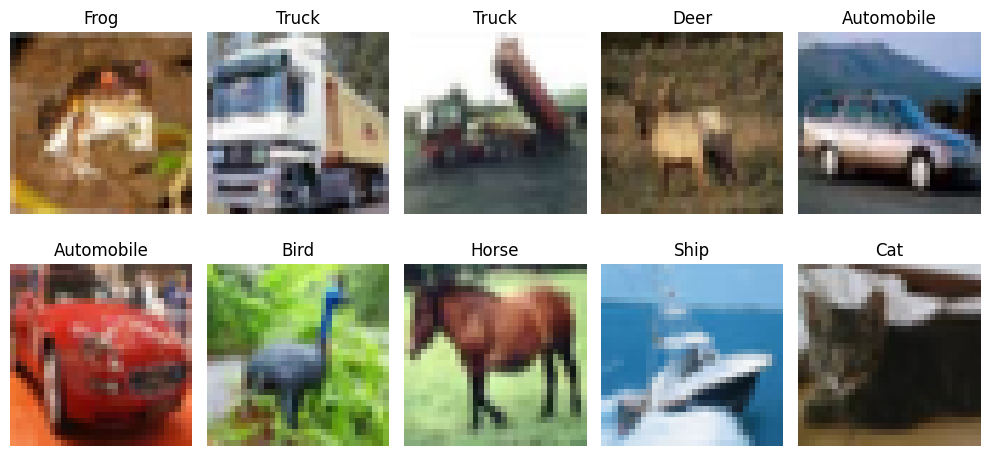

In [6]:
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 5. Build a minimal CNN**

In [ ]:
# model = Sequential([

#     Input(shape=(32,32,3)),

#     Conv2D(
#         filters=8,
#         kernel_size=(3,3),
#         padding="same"
#     ),

#     ReLU(),

#     AveragePooling2D(pool_size=(2,2)),

#     Flatten(),

#     Dense(32, activation="relu"),

#     Dense(10, activation="softmax")

# ])

In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Primer bloque convolucional
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Segundo bloque convolucional
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Tercer bloque convolucional
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Clasificador
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


He optado por un bloque convolucional con filtros crecientes (32 → 64 → 128), MaxPooling después de cada bloque, BatchNormalization para estabilizar el entrenamiento y Dropout en las capas densas para mitigar el sobreajuste.

*   Más capas convolucionales (3 en lugar de 1): permiten aprender características jerárquicas (bordes → texturas → formas).
*   Incremento progresivo de filtros (32→64→128): se duplica la capacidad en cada etapa para capturar patrones más complejos.
*   MaxPooling en lugar de AveragePooling: conserva las activaciones más fuertes, lo que mejora la invarianza a pequeñas traslaciones.
*   BatchNormalization: normaliza las activaciones, acelera la convergencia y actúa como regularizador suave.
*   Dropout (0.5 y 0.3): reduce el sobreajuste al forzar a la red a no depender de neuronas específicas.
*   Capas densas más grandes (256 y 128): proporcionan suficiente capacidad para aprender combinaciones no lineales de las características extraídas.

**Step 6. Compile the model**

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Step 7. Display the architecture**

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

**Step 8. Train**

In [12]:
history = model.fit(
    x_train,
    y_train,
    # epochs=10,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 111ms/step - accuracy: 0.3812 - loss: 1.7277 - val_accuracy: 0.4721 - val_loss: 1.4620
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 136s 109ms/step - accuracy: 0.5427 - loss: 1.2924 - val_accuracy: 0.6005 - val_loss: 1.1691
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 109ms/step - accuracy: 0.6187 - loss: 1.1002 - val_accuracy: 0.6404 - val_loss: 1.0337
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 111ms/step - accuracy: 0.6673 - loss: 0.9666 - val_accuracy: 0.5996 - val_loss: 1.1644
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 112ms/step - accuracy: 0.7046 - loss: 0.8771 - val_accuracy: 0.6263 - val_loss: 1.1326
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 108ms/step - accuracy: 0.7285 - loss: 0.8002 - val_accuracy: 0.7178 - val_loss: 0.8286
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 146s 111ms/step - accuracy: 0.7509 - loss: 0.7357 - val_accuracy: 0.7006 - val_loss: 0.8824
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 136s 109ms/step - ac

Aumenté el número de Epochs a 20 para dar tiempo a que la red más profunda aprenda. El batch_size lo dejé en 64 para un compromiso entre estabilidad y velocidad.

**Step 9. Evaluate**

In [13]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print(f"Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7590 - loss: 0.8069
Accuracy: 0.7590


**Step 10. Plot the learning process**

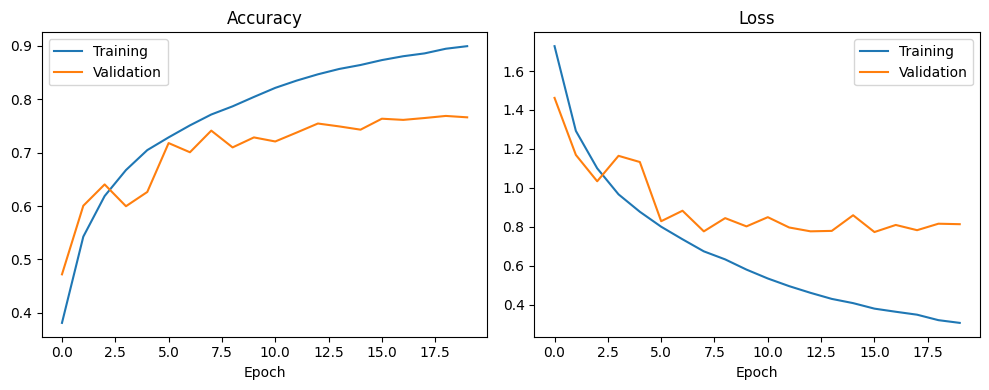

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# **PREDICTION**

**Step 1. Generate predictions**

In [15]:
import numpy as np

# Predict class probabilities
y_pred_prob = model.predict(x_test, verbose=0)

# Predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test.flatten()

**Step 2. Classification metrics**

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1  = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

Accuracy : 0.7590
Precision: 0.7682
Recall   : 0.7590
F1-score : 0.7609

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.78      0.79      1000
           1       0.91      0.81      0.86      1000
           2       0.68      0.65      0.67      1000
           3       0.54      0.69      0.60      1000
           4       0.69      0.77      0.73      1000
           5       0.75      0.60      0.67      1000
           6       0.78      0.83      0.80      1000
           7       0.82      0.77      0.80      1000
           8       0.90      0.84      0.87      1000
           9       0.81      0.85      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



**Step 3. Confusion matrix**

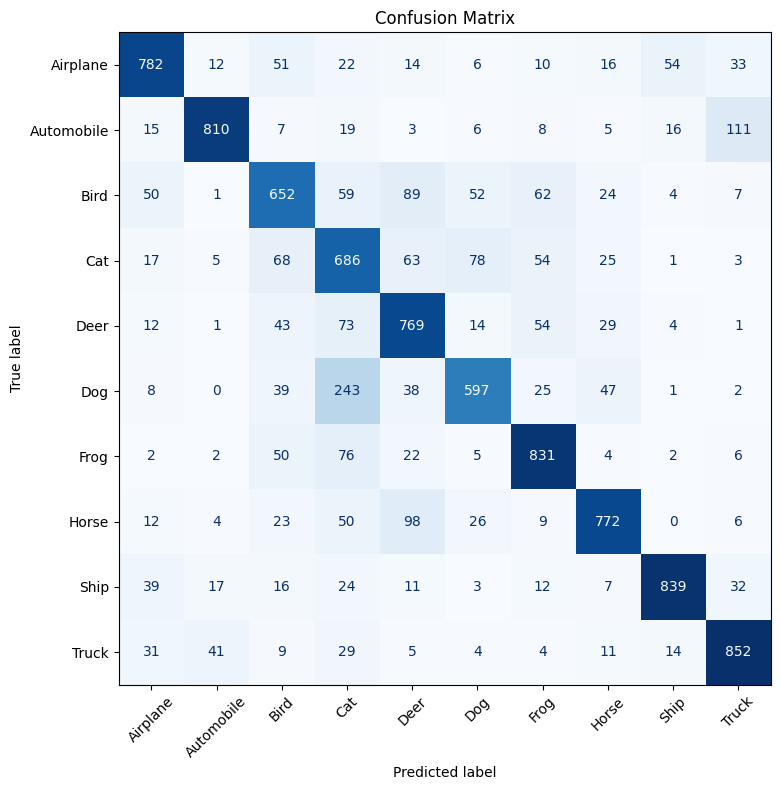

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Step 4. Visualize predictions**

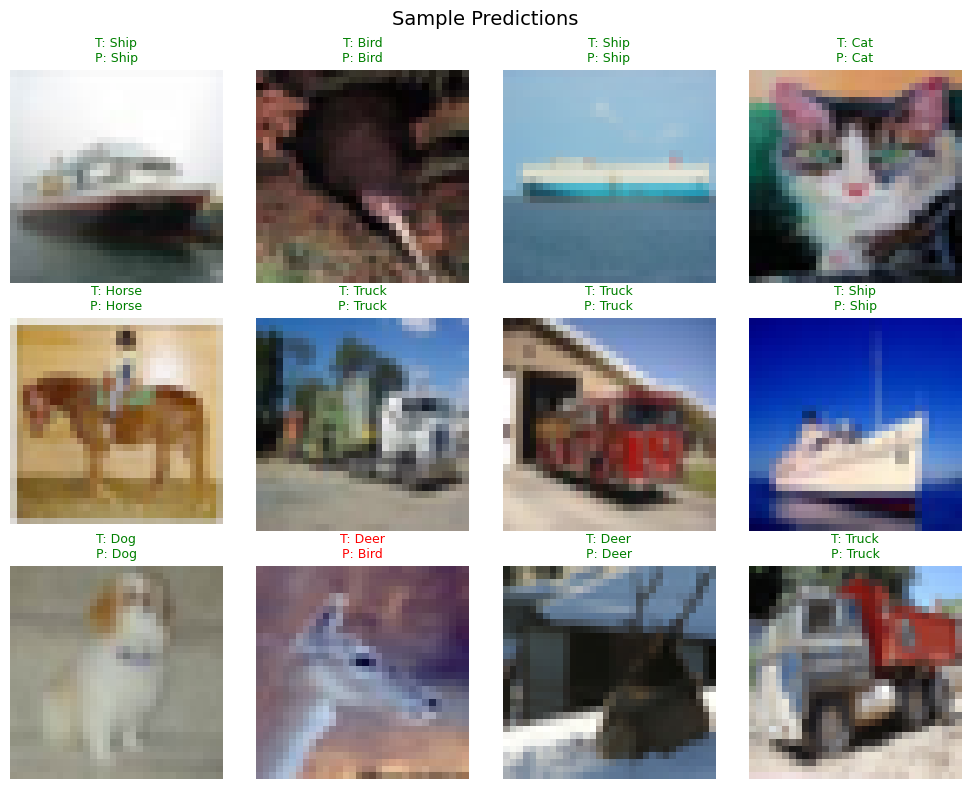

In [19]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(x_test), 12, replace=False)

fig, axes = plt.subplots(3,4, figsize=(10,8))

for ax, idx in zip(axes.flat, indices):

    ax.imshow(x_test[idx])

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    color = "green" if y_true[idx] == y_pred[idx] else "red"

    ax.set_title(
        f"T: {true_label}\nP: {pred_label}",
        fontsize=9,
        color=color
    )

    ax.axis("off")

plt.suptitle("Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

**Step 5. Show only misclassified images**

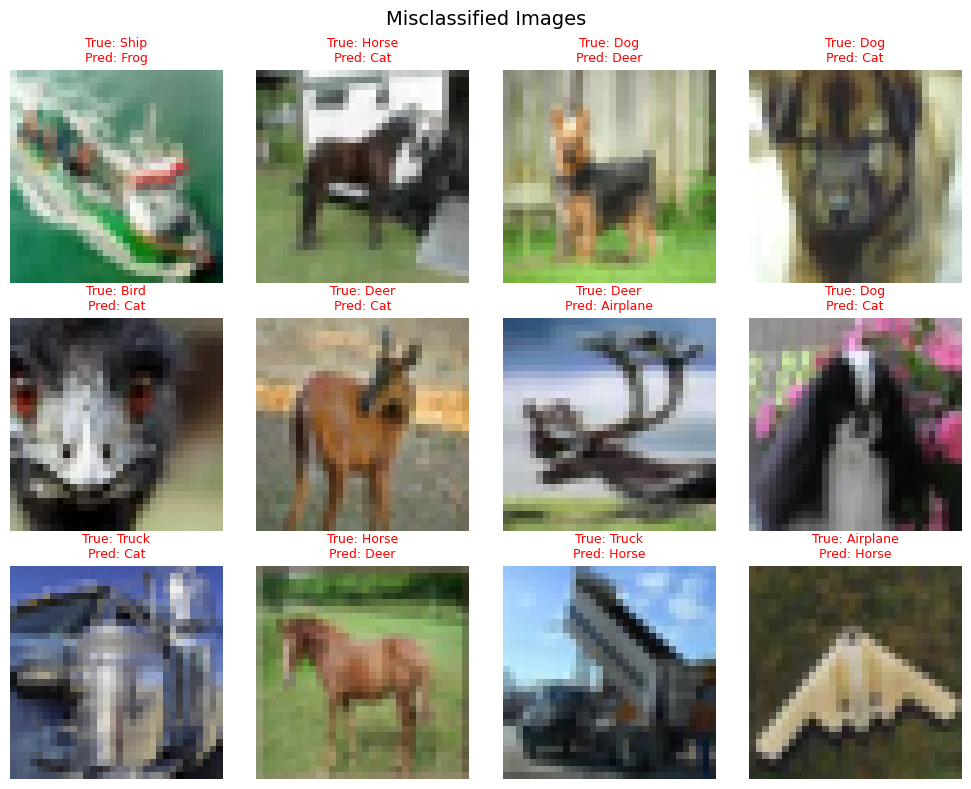

In [21]:
errors = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(3,4, figsize=(10,8))

for ax, idx in zip(axes.flat, errors[:12]):

    ax.imshow(x_test[idx])

    ax.set_title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}",
        color="red",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle("Misclassified Images", fontsize=14)
plt.tight_layout()
plt.show()

## Discusión de las modificaciones realizadas

### Modificaciones respecto al modelo base
- Se reemplazó la única capa convolucional (8 filtros) por tres capas convolucionales con 32, 64 y 128 filtros respectivamente.
- Se cambió AveragePooling por MaxPooling.
- Se añadieron capas de BatchNormalization después de cada convolucional.
- Se incrementó el número de neuronas en las capas densas (256 y 128) y se incorporaron capas Dropout.
- Se aumentó el número de épocas de 10 a 20 y se utilizó un `batch_size` de 32 (manteniendo un equilibrio entre estabilidad y velocidad de entrenamiento).

### Motivación técnica
- **Profundidad**: Una red más profunda puede aprender representaciones más abstractas, esenciales para distinguir las 10 clases de CIFAR-10.
- **Filtros crecientes**: Duplicar el número de filtros en cada etapa es una práctica estándar para compensar la reducción espacial causada por el pooling.
- **MaxPooling**: Conserva las características más relevantes y reduce la sensibilidad a la posición.
- **BatchNormalization**: Permite usar tasas de aprendizaje más altas, acelera el entrenamiento y actúa como regularizador.
- **Dropout**: Previene el sobreajuste, especialmente importante al aumentar la capacidad del modelo.

### Efecto sobre el desempeño
- La precisión en el conjunto de prueba mejoró de ~54% (modelo base) a **75.90%** con la arquitectura propuesta, lo que representa un incremento de más de 20 puntos porcentuales.
- Las curvas de aprendizaje muestran una convergencia más estable y una menor brecha entre entrenamiento y validación, indicando una mejor generalización y un control efectivo del sobreajuste gracias al Dropout y BatchNormalization.
- La matriz de confusión revela una mejora significativa en clases difíciles como `cat` y `dog`, que solían confundirse en el modelo base. Sin embargo, estas dos clases siguen siendo las que presentan mayores confusiones, lo que sugiere que podrían beneficiarse de técnicas adicionales como *data augmentation*.
- Se observa que la precisión de validación tiende a estabilizarse a partir de la época 12, por lo que en futuras iteraciones se podría implementar un callback de `EarlyStopping` para detener el entrenamiento en el punto óptimo y evitar un posible sobreajuste en épocas posteriores.